In [ ]:
import marimo as mo  # noqa: F401
import matplotlib.pyplot as plt
import torch
from box import Box  # converts dicts to dot notation access.

from flow_matching import (
    ConditionalVectorFieldODE,
    ConditionalVectorFieldSDE,
    GaussianConditionalProbabilityPath,
    LinearAlpha,
    SquareRootBeta,
)
from flow_matching.distributions import Gaussian, GaussianMixture
from flow_matching.plot import imshow_density, plot_conditional_probability_path, plot_flow_path


In [ ]:
device = torch.device(  # noqa: F841
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)


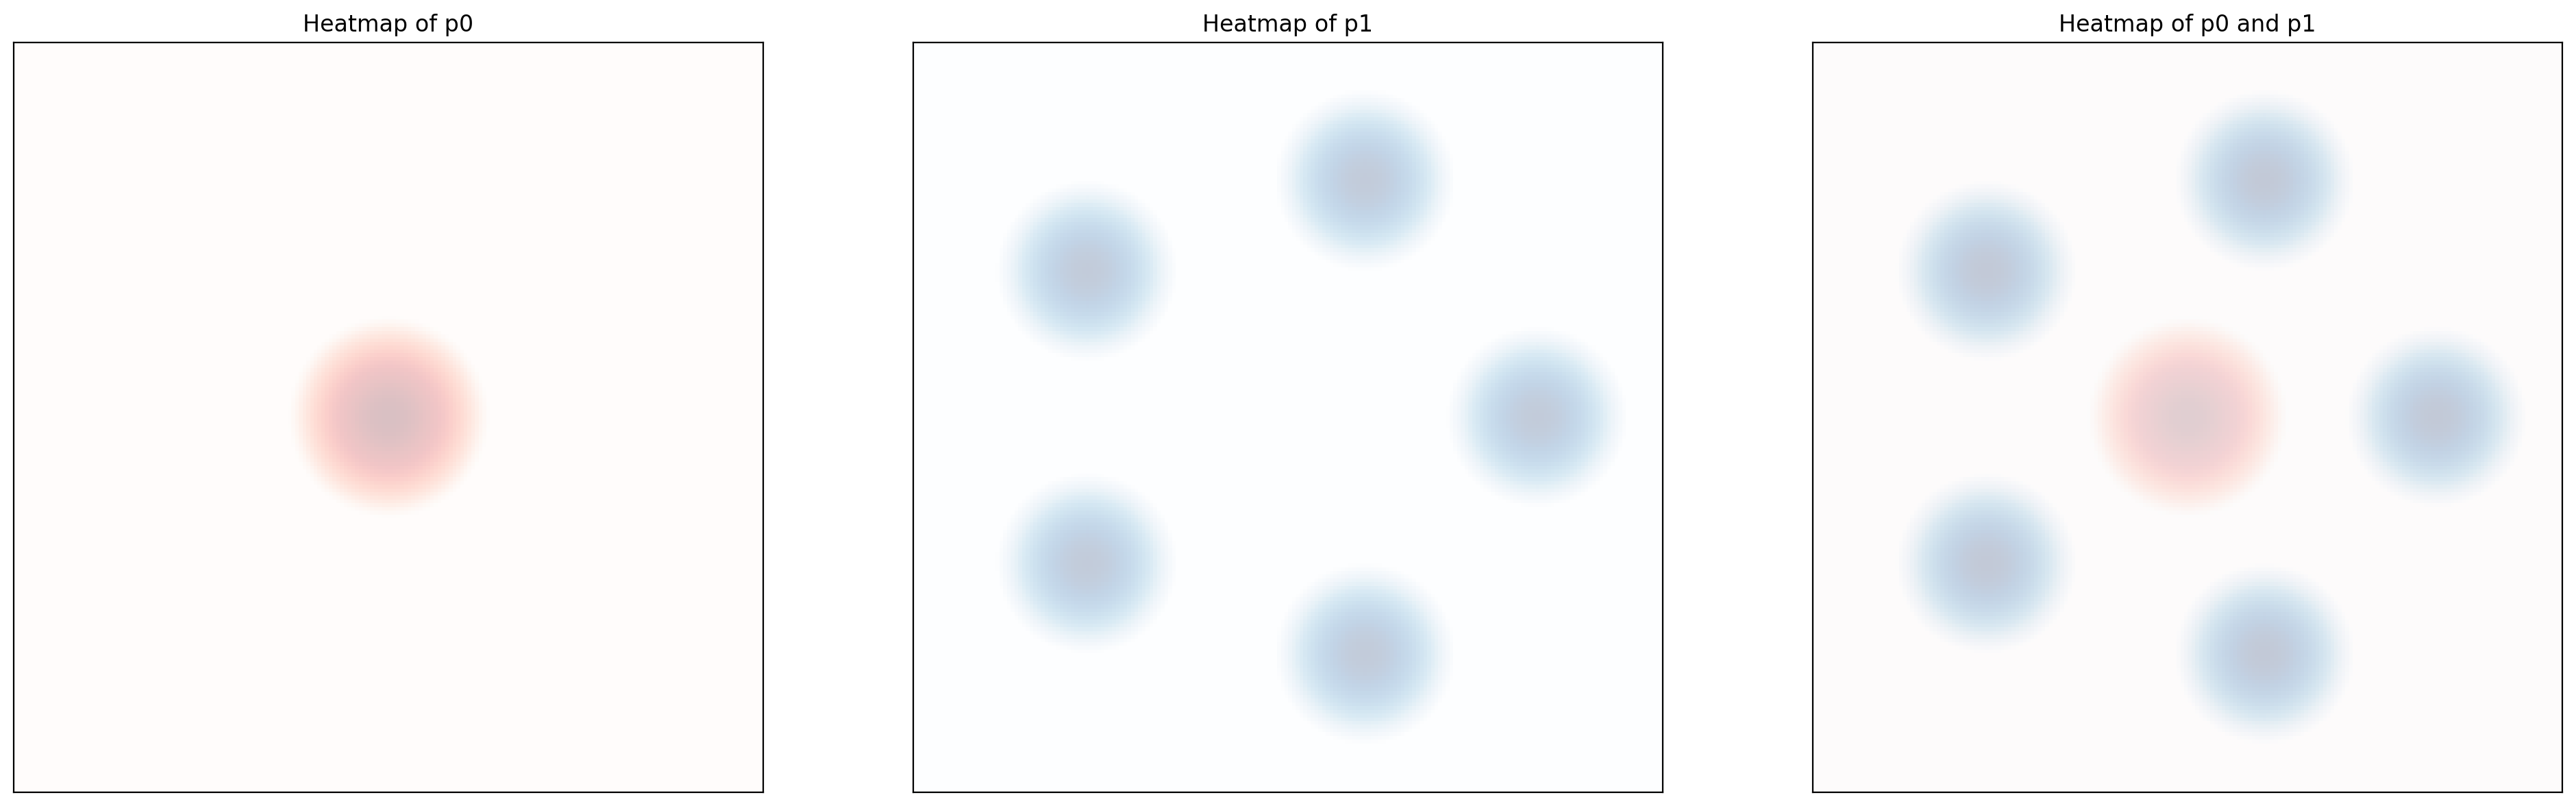

In [ ]:
_params = Box(
    {
        "scale": 15.0,
        "target_scale": 10.0,
        "target_std": 1.0,
    }
)
# initial distribution
p0 = Gaussian.isotropic(dim=2, std=1.0).to(device)
# target
p1 = GaussianMixture.symmetric_2D(nmodes=5, std=_params.target_std, scale=_params.target_scale).to(
    device
)

fig_gs, axes_gs = plt.subplots(1, 3, figsize=(24, 8))
bins = 200

scale = _params.scale
x_bounds_gs = (-scale, scale)
y_bounds_gs = (-scale, scale)

axes_gs[0].set_title("Heatmap of p0")
axes_gs[0].set_xticks([])
axes_gs[0].set_yticks([])
imshow_density(
    density=p0,
    x_bounds=x_bounds_gs,
    y_bounds=y_bounds_gs,
    bins=bins,
    ax=axes_gs[0],
    vmin=-10,
    alpha=0.25,
    cmap=plt.get_cmap("Reds"),
)

axes_gs[1].set_title("Heatmap of p1")
axes_gs[1].set_xticks([])
axes_gs[1].set_yticks([])
imshow_density(
    density=p1,
    x_bounds=x_bounds_gs,
    y_bounds=y_bounds_gs,
    bins=bins,
    ax=axes_gs[1],
    vmin=-10,
    alpha=0.25,
    cmap=plt.get_cmap("Blues"),
)

axes_gs[2].set_title("Heatmap of p0 and p1")
axes_gs[2].set_xticks([])
axes_gs[2].set_yticks([])
imshow_density(
    density=p0,
    x_bounds=x_bounds_gs,
    y_bounds=y_bounds_gs,
    bins=bins,
    vmin=-10,
    alpha=0.25,
    cmap=plt.get_cmap("Reds"),
)
imshow_density(
    density=p1,
    x_bounds=x_bounds_gs,
    y_bounds=y_bounds_gs,
    bins=bins,
    vmin=-10,
    alpha=0.25,
    cmap=plt.get_cmap("Blues"),
)
plt.show()


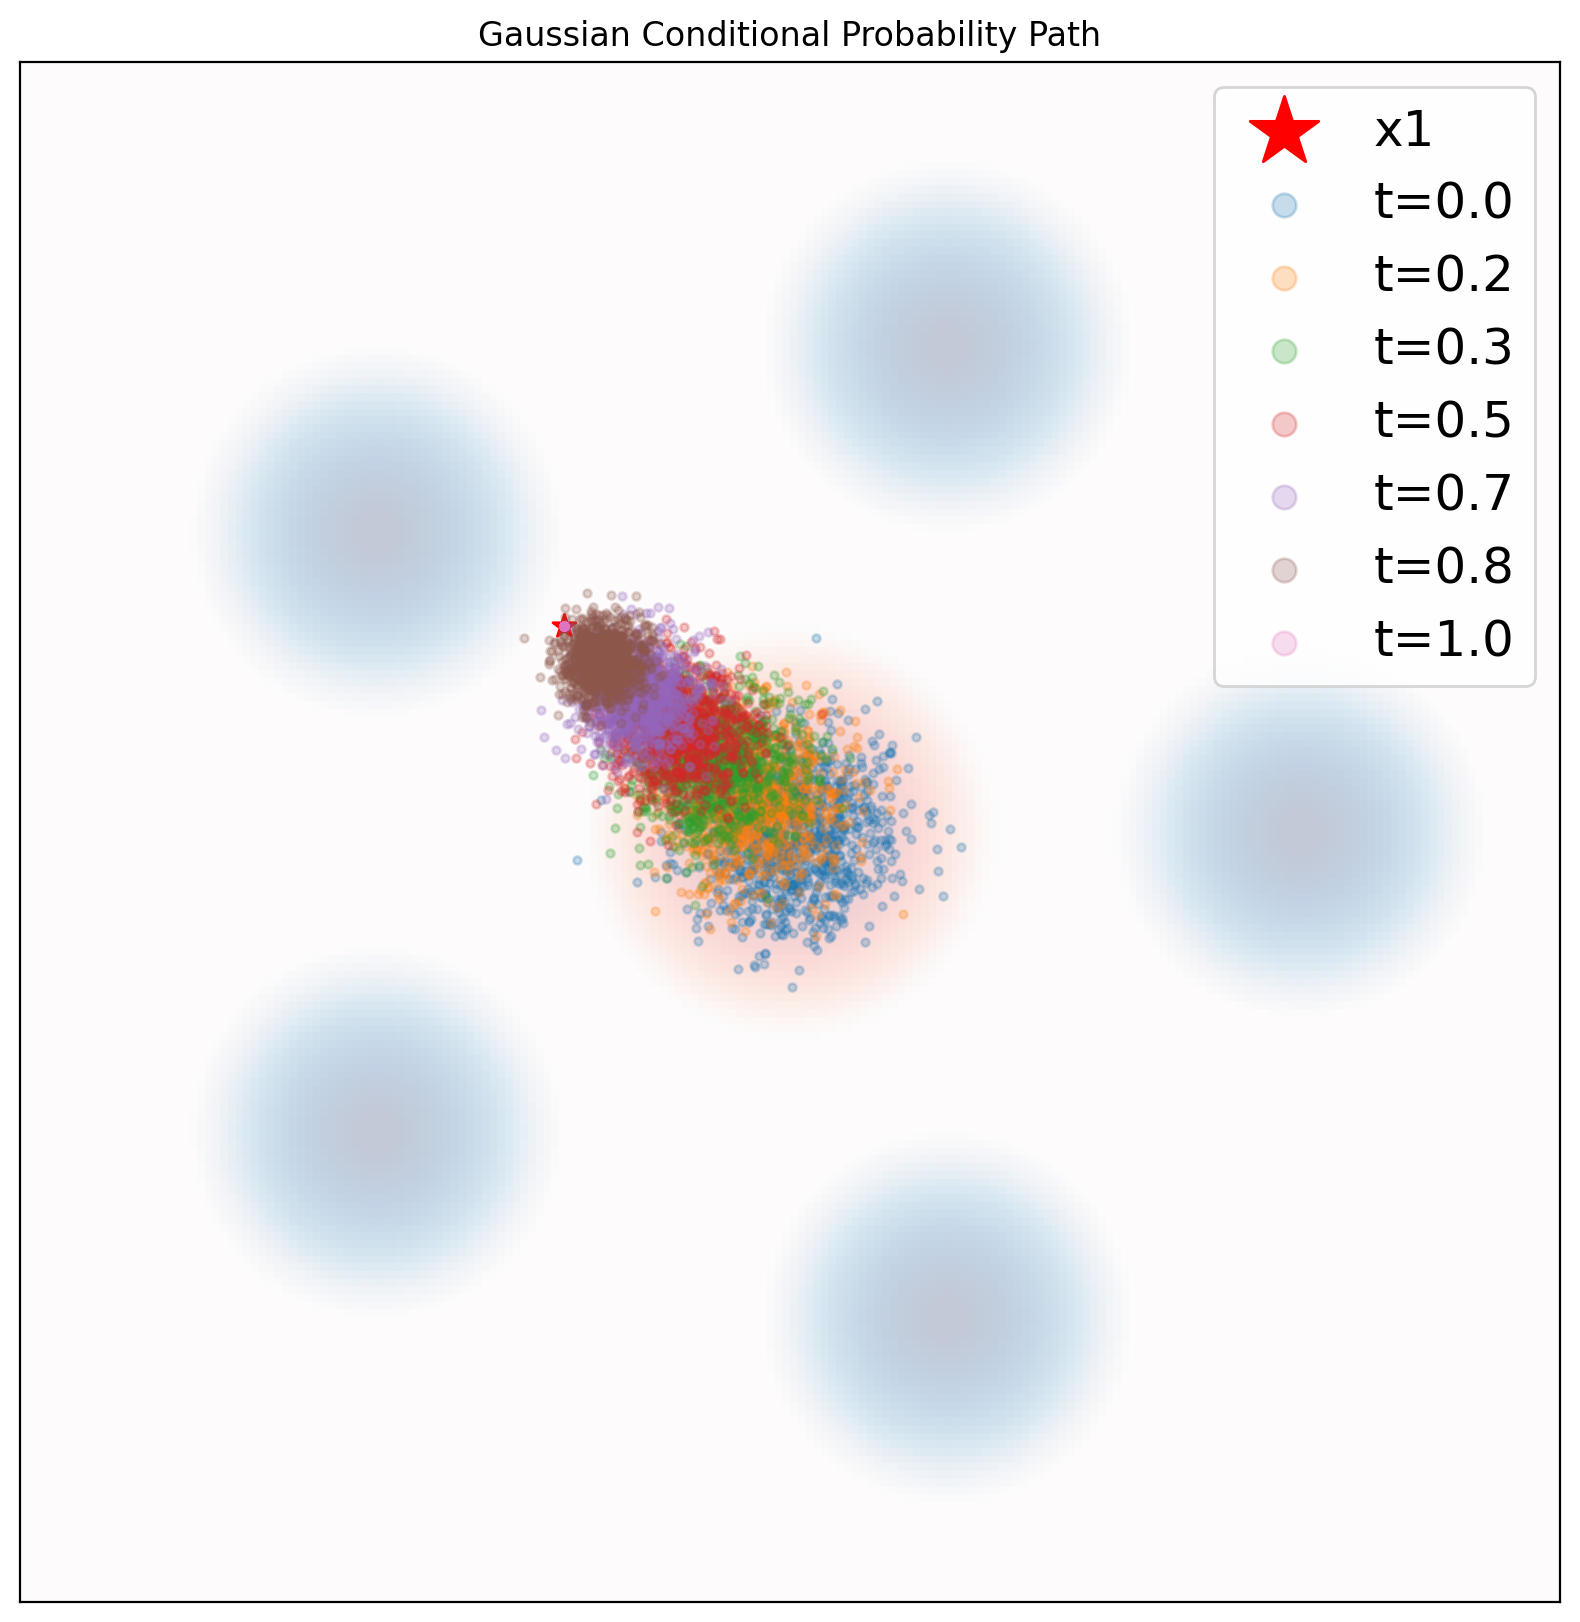

In [ ]:
plot_conditional_probability_path()



100%|████████████████████████████████████████████████████████████████████| 99/99 [00:00<00:00, 1108.01it/s]


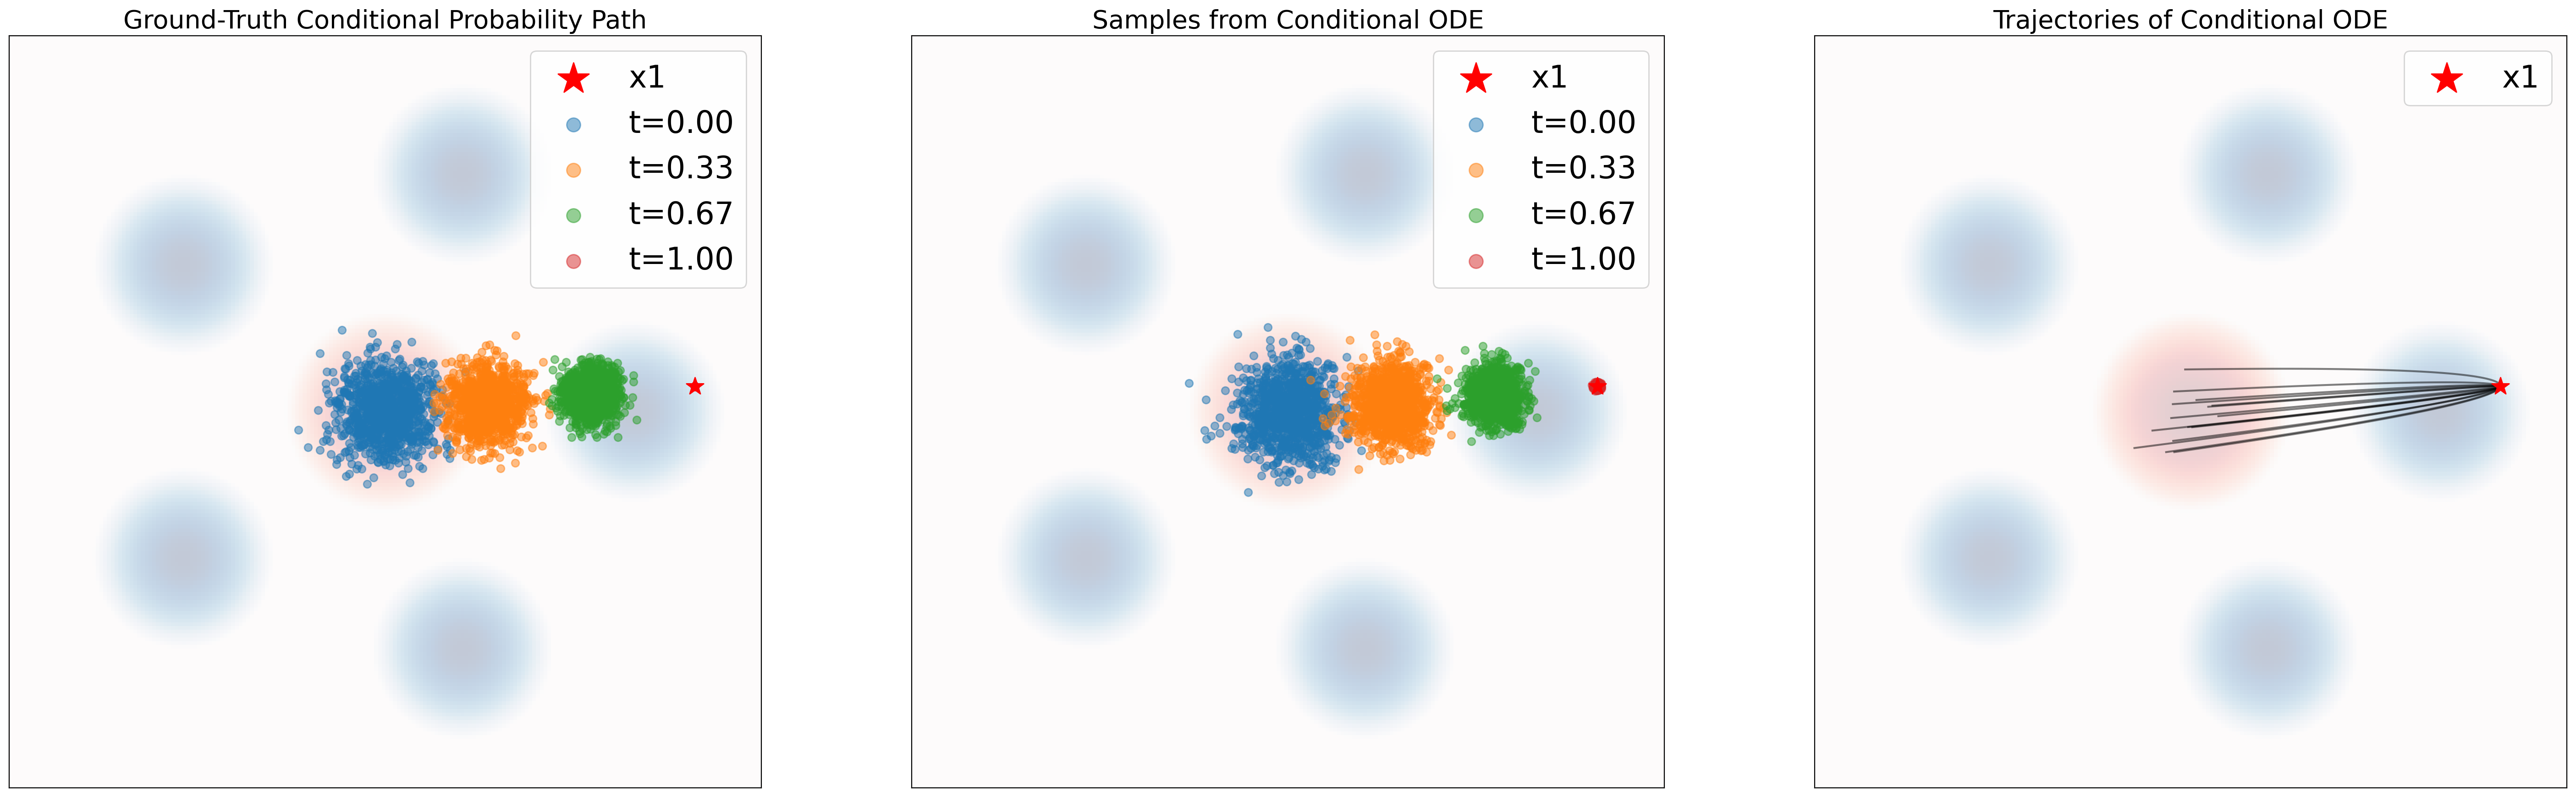

In [ ]:
# Plot ODE flow
params: Box = Box(
    {
        "scale": 15.0,
        "target_scale": 10.0,
        "target_std": 1.0,
        "sigma": 2.5,
    }
)
# Construct path and vector field
p_simple: Gaussian = Gaussian.isotropic(dim=2, std=1.0).to(device)
p_data: GaussianMixture = GaussianMixture.symmetric_2D(
    nmodes=5, std=params.target_std, scale=params.target_scale
).to(device)
alpha = LinearAlpha()
beta = SquareRootBeta()
path = GaussianConditionalProbabilityPath(p1=p_data, alpha=alpha, beta=beta)
torch.manual_seed(1)
x1: torch.Tensor = path.sample_conditioning_variable(1)
conditional_vector_field_ode = ConditionalVectorFieldODE(path, x1)
plot_flow_path(conditional_vector_field_ode, path, p_simple, p_data, x1, params)



100%|█████████████████████████████████████████████████████████████████████| 99/99 [00:00<00:00, 545.46it/s]


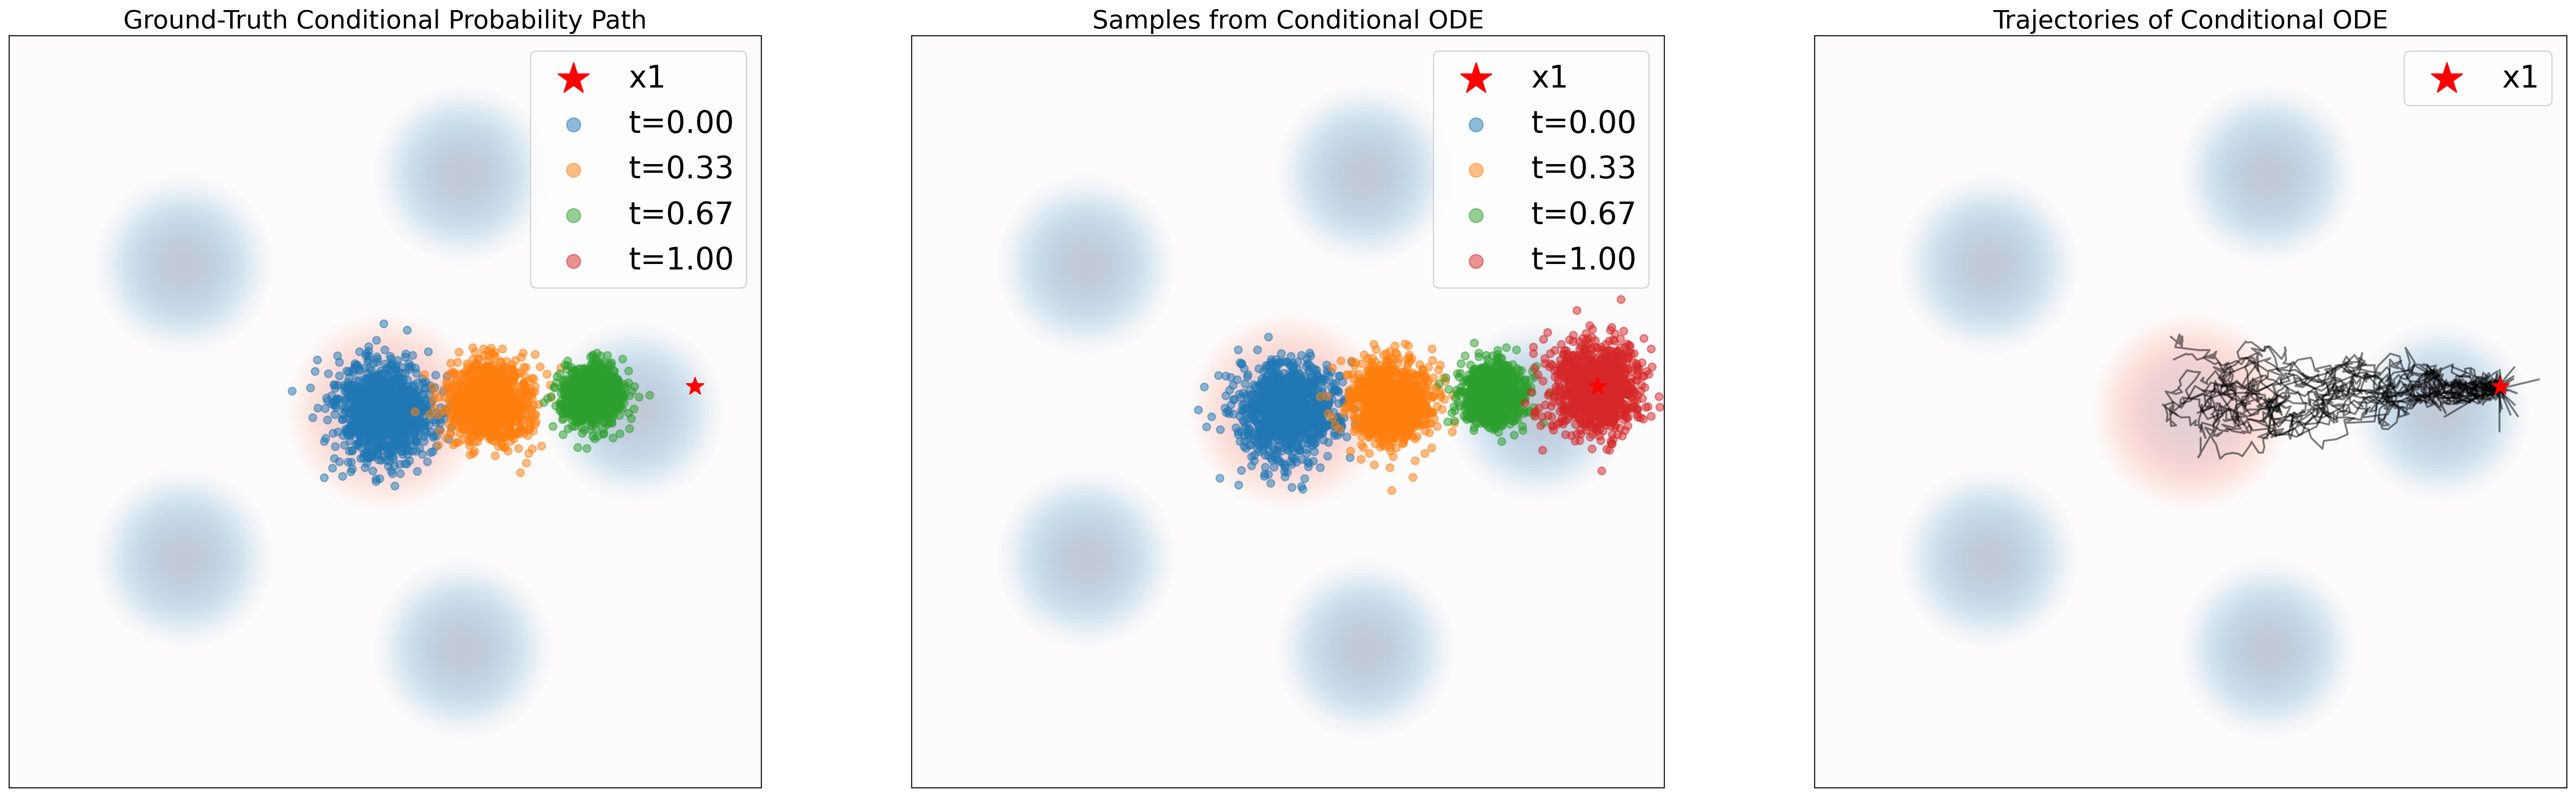

In [ ]:
conditional_vector_field_sde = ConditionalVectorFieldSDE(path, x1, sigma=params.sigma)
plot_flow_path(conditional_vector_field_sde, path, p_simple, p_data, x1, params)


# Flow Matching and Score Matching Training

In [ ]:
from flow_matching.models import MLPVectorField
from flow_matching.trainer import ConditionalFlowMatchingTrainer

path_flow = GaussianConditionalProbabilityPath(
    p1=GaussianMixture.symmetric_2D(nmodes=5, std=params.target_std, scale=params.target_scale).to(
        device
    ),
    alpha=LinearAlpha(),
    beta=SquareRootBeta(),
).to(device)
flow_model = MLPVectorField(dim=2, hidden_dims=[64, 64, 64, 64]).to(device)
trainer = ConditionalFlowMatchingTrainer(path=path_flow, model=flow_model)
_losses = trainer.train(num_epochs=5000, device=device, lr=1e-3, batch_size=1000)  # type: ignore[reportArgumentType]



0it [00:00, ?it/s]
0it [00:01, ?it/s]


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, mps:0 and cpu!